In [28]:
from google.colab import drive        # Mount Google Drive
import pandas as pd                  # Data loading & manipulation
import numpy as np                   # Numerical operations
import matplotlib.pyplot as plt      # Plotting
import seaborn as sns                # Feature importance bar plot
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [29]:
# Load dataset from Google Drive
path = "/content/drive/MyDrive/data/ai4i2020.csv"
df = pd.read_csv(path)

# Preview the first 5 rows
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [30]:
df.info() # get summary of data
df.describe() # get statistical summary of columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [16]:
df['Machine failure'].value_counts()


,count
Machine failure,
0,9661
1,339


In [17]:
# Drop unnecessary ID columns
df_clean = df.drop(columns=['UDI', 'Product ID'])

# Check missing values
print("Missing values before cleaning:")
print(df_clean.isnull().sum())

# Drop missing values
df_clean = df_clean.dropna()


Missing values before cleaning:
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [31]:
# Encode Type column into numeric values
df_clean['Type'] = df_clean['Type'].map({
    'L': 0,
    'M': 1,
    'H': 2
})


In [19]:
# creating new feature: Temperature difference
df_clean['Temp_diff'] = (
    df_clean['Process temperature [K]'] -
    df_clean['Air temperature [K]']
)

# Mechanical power estimation
df_clean['Power'] = (
    df_clean['Torque [Nm]'] *
    df_clean['Rotational speed [rpm]']
)

# Calculate tool wear rate
df_clean['Tool_wear_rate'] = (
    df_clean['Tool wear [min]'] /
    df_clean['Rotational speed [rpm]'] # To avoid division errors
)


In [20]:
# Separate features (x) and target (y)
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (10000, 14)
y shape: (10000,)


In [21]:
# standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Temp_diff,Power,Tool_wear_rate
0,NaN,-0.952389,-0.947360,0.068185,0.282200,-1.695984,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,0.498849,0.629443,-1.665187
1,NaN,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,0.498849,0.512456,-1.615191
2,NaN,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,0.398954,1.376889,-1.586867
3,NaN,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,0.398954,-0.330009,-1.550565
4,NaN,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363,0.498849,-0.357824,-1.515199


In [22]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (8000, 14)
Testing set: (2000, 14)


In [23]:
# 2. Define the Random Forest model
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'  # handles class imbalance
)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# 4. Randomized Search with Cross-Validation
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

# 5. Best model and parameters
best_rf = random_search.best_estimator_

print("___________________________________________")
print("Best Hyperparameters:")
print(random_search.best_params_)
print("Best Cross-Validated F1 Score:")
print(random_search.best_score_)
print("___________________________________________\n")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Best Cross-Validated F1 Score:
0.9867738116230445



In [24]:
# Make predictions on the test set
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Best Parameters:", random_search.best_params_)
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
F1 Score: 0.9696969696969697
ROC-AUC: 0.986317896723907

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.94      0.97        68

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000



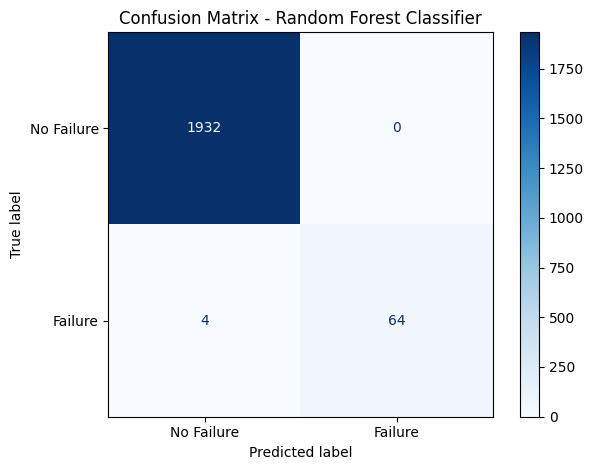

In [26]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.tight_layout()
plt.show()


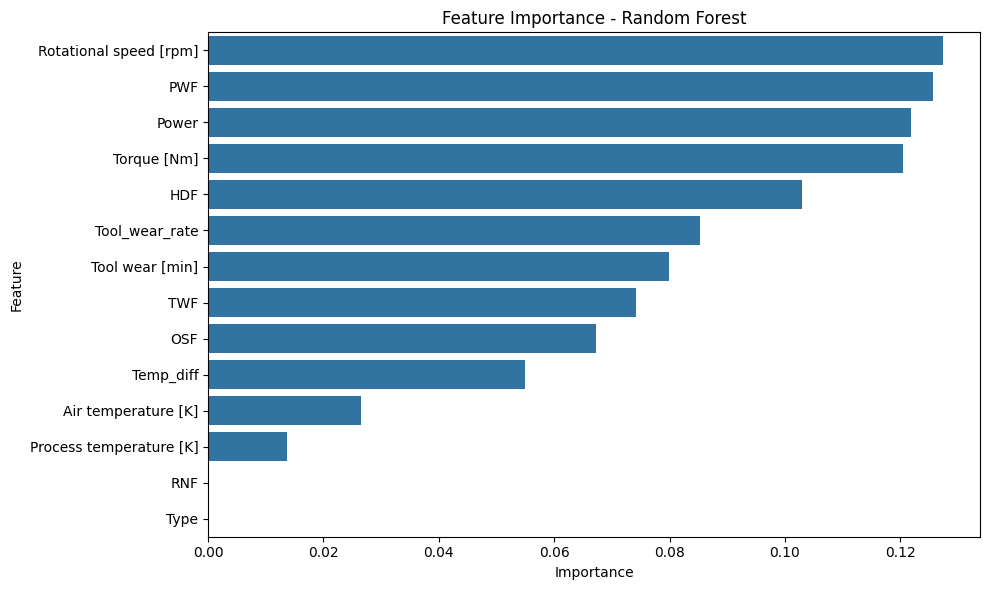

Top 10 Features:


,Feature,Importance
3,Rotational speed [rpm],0.127447
8,PWF,0.125625
12,Power,0.121786
4,Torque [Nm],0.120470
7,HDF,0.102877
13,Tool_wear_rate,0.085207
5,Tool wear [min],0.079860
6,TWF,0.074160
9,OSF,0.067262
11,Temp_diff,0.054932


In [25]:
# Get feature importances from the trained Random Forest
importances = best_rf.feature_importances_
features = X_train.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances as a horizontal bar chart
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

print("Top 10 Features:")
feat_df.head(10)


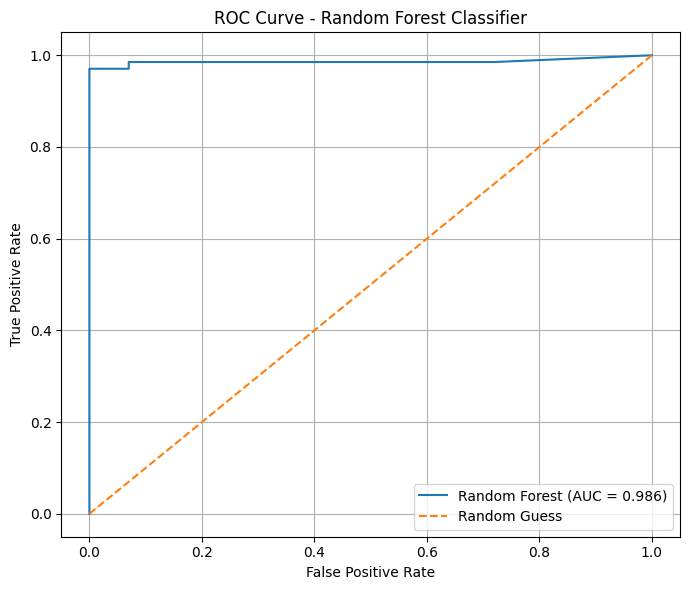

In [27]:
# Get predicted probabilities for the positive class
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
